# Import Libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Load Data

In [72]:
probabilities = pd.read_csv("../data/results/wc2026_predictions_10,000_20260613_2214.csv")
wc2026_draw = pd.read_csv("../data/processed/wc2026_draw_clean.csv")
elo = pd.read_csv("../data/processed/elo_clean.csv")

# Visualisations
## Most Likely Winners

Bar chart of the top 10 contenders for the World Cup 2026 according to the model.

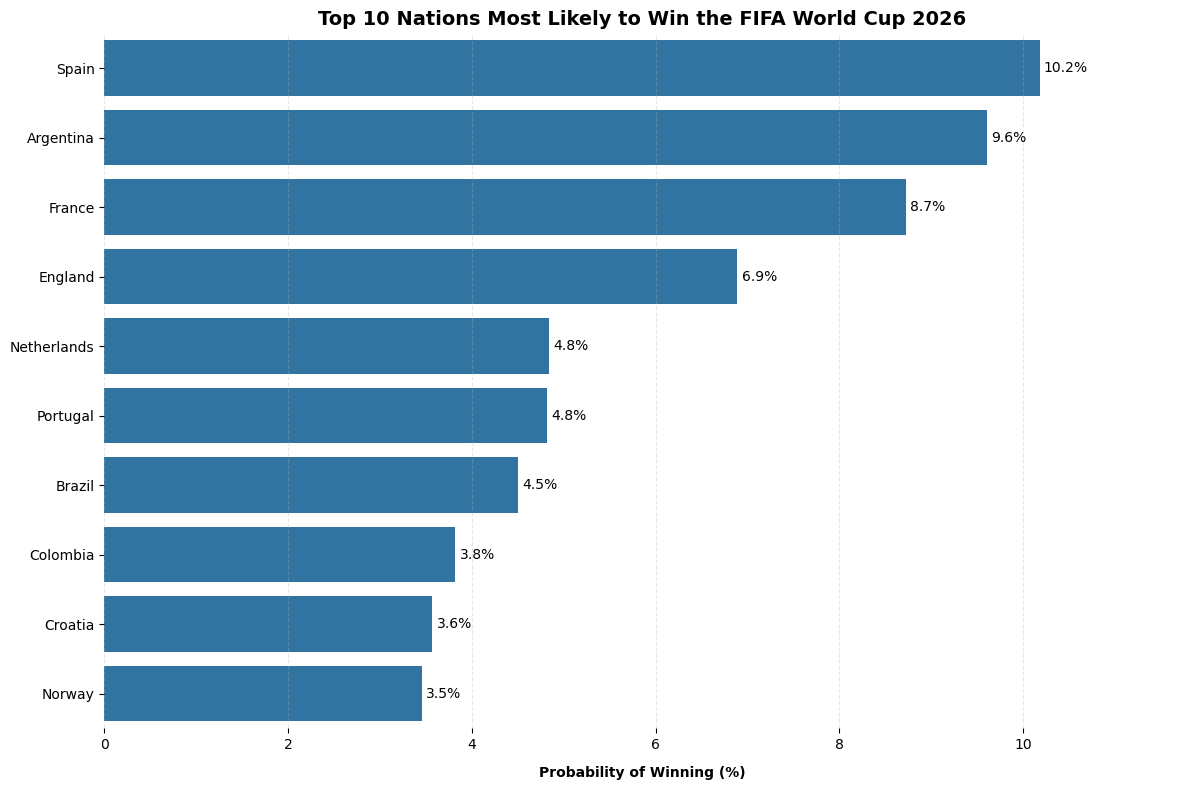

In [53]:
most_likely_winners = probabilities.head(10).copy()
most_likely_winners["champion_prob"] = most_likely_winners["champion_prob"].apply(lambda x: x*100)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=most_likely_winners,
    x="champion_prob",
    y="country"
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10
    )

plt.title("Top 10 Nations Most Likely to Win the FIFA World Cup 2026", fontsize=14, fontweight="bold")
plt.xlabel("Probability of Winning (%)", labelpad=10, fontweight="bold")
plt.ylabel("")

# Remove unnecessary borders
sns.despine(left=True, bottom=True)

# Add subtle gridlines
plt.grid(axis="x", linestyle="--", alpha=0.3)

# Leave some room for labels
plt.xlim(0, most_likely_winners["champion_prob"].max() * 1.15)

plt.tight_layout()

plt.show()

According to the model, the top 3 contenders to win the 2026 FIFA World Cup are Spain, Argentina and France. Spain emerges as the country with the highest probability at 10.2%. This result aligns closely with current perceptions of international football, as well as other well-known predictions.

Interestingly, the model also predicts Norway to be the dark horse of the tournament, with it appearing in the top 10 countries with the highest probability to win the world cup.

## Probability Heatmap

Heatmap of the odds for the top 15 most likely winners to reach each stage of the 2026 World Cup.

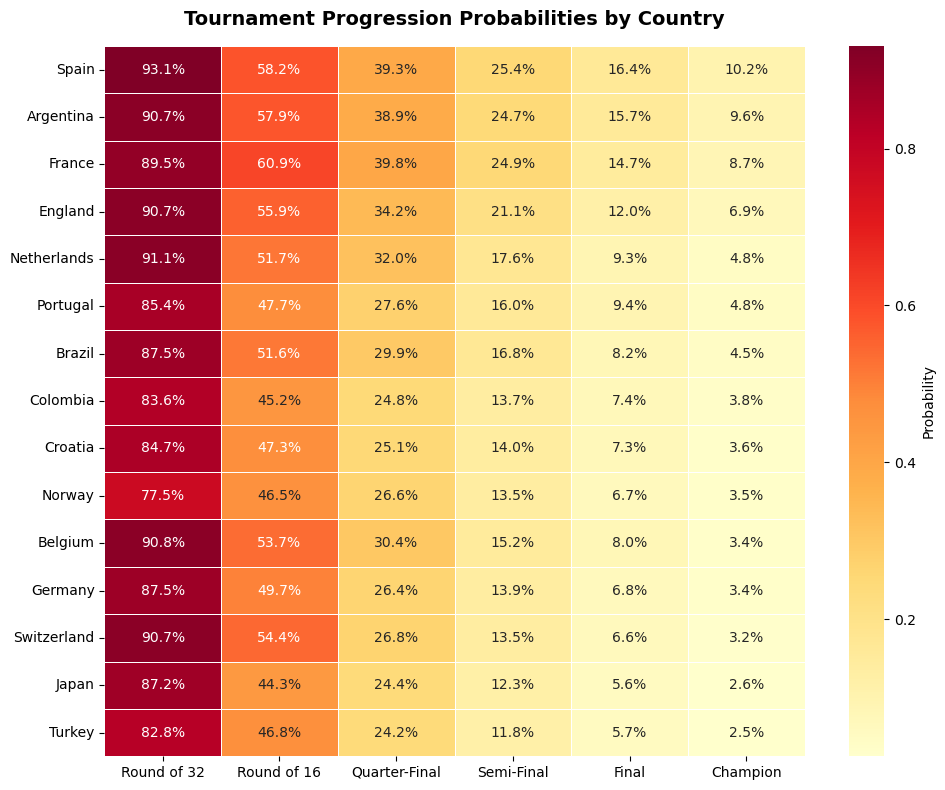

In [54]:
fig, ax = plt.subplots(figsize=(10, 8))

stages_top15 = probabilities[
    ["country",
     "r32_prob",
     "r16_prob",
     "quarter_final_prob",
     "semi_final_prob",
     "final_prob",
     "champion_prob"]
].head(15)

sns.heatmap(
    stages_top15.set_index("country"),
    annot=True,
    fmt=".1%",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Probability"},
    ax=ax
)

ax.set_title("Tournament Progression Probabilities by Country", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(
    ["Round of 32", "Round of 16", "Quarter-Final", "Semi-Final", "Final", "Champion"],
    rotation=0
)

plt.tight_layout()
plt.show()

According to the model,
- Despite Norway having the tenth highest probability of winning the world cup, the probability of them reaching the Round of 32 is distinctly lower than that of other countries in the list of top 15 contenders.  
- Belgium, Switzerland, Germany and Japan have considerably high chances of reaching the Round of 32, but face a lower chance of winning the tournament. 

## Predicted Performance of 2026 World Cup Hosts

Line chart depicting the probability of each host nation reaching each knockout stage.

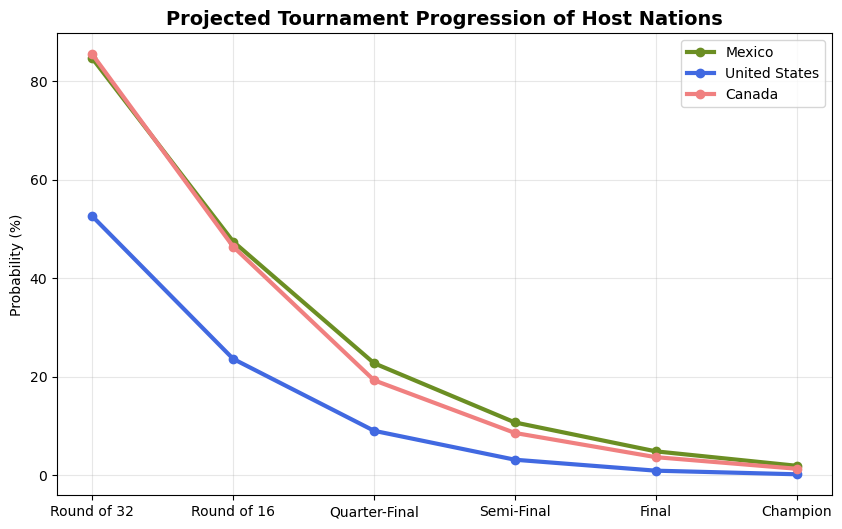

In [68]:
hosts = ["Mexico", "United States", "Canada"]
stages = ["Round of 32", "Round of 16", "Quarter-Final", "Semi-Final", "Final", "Champion"]
stage_cols = ["r32_prob", "r16_prob", "quarter_final_prob", "semi_final_prob", "final_prob", "champion_prob"]

colours = {
    "Mexico": "olivedrab",
    "United States": "royalblue",
    "Canada": "lightcoral"
}

plt.figure(figsize=(10,6))

for country in hosts:
    row = probabilities[probabilities["country"] == country].iloc[0]

    plt.plot(
        stages,
        [row[col] * 100 for col in stage_cols],
        marker="o",
        linewidth=3,
        color=colours[country],
        label=country
    )

plt.ylabel("Probability (%)")
plt.title("Projected Tournament Progression of Host Nations", fontweight="bold", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

- The model predicts USA to have a relatively low chance of making it out of the group stage compared to the other host nations. This could be due to the USA's allocated group being more competitive as all four nations in the group have comparable Elo ratings, as discussed in the EDA notebook of this project.
- Overall, the model predicts Mexico to perform better than Canada, followed by the USA.

## Correlation between Elo Ratings and Championship Probability

In [83]:
# Create dataframe of each country's latest elo ratings
wc2026_countries = wc2026_draw["country"].tolist()
elo_ratings_wc2026 = elo[elo["country_full"].isin(wc2026_countries)]
elo_ratings_wc2026 = elo_ratings_wc2026[elo_ratings_wc2026["rank_date"] == "2026-04-01"]

Scatter plot of championship probability against elo ratings.

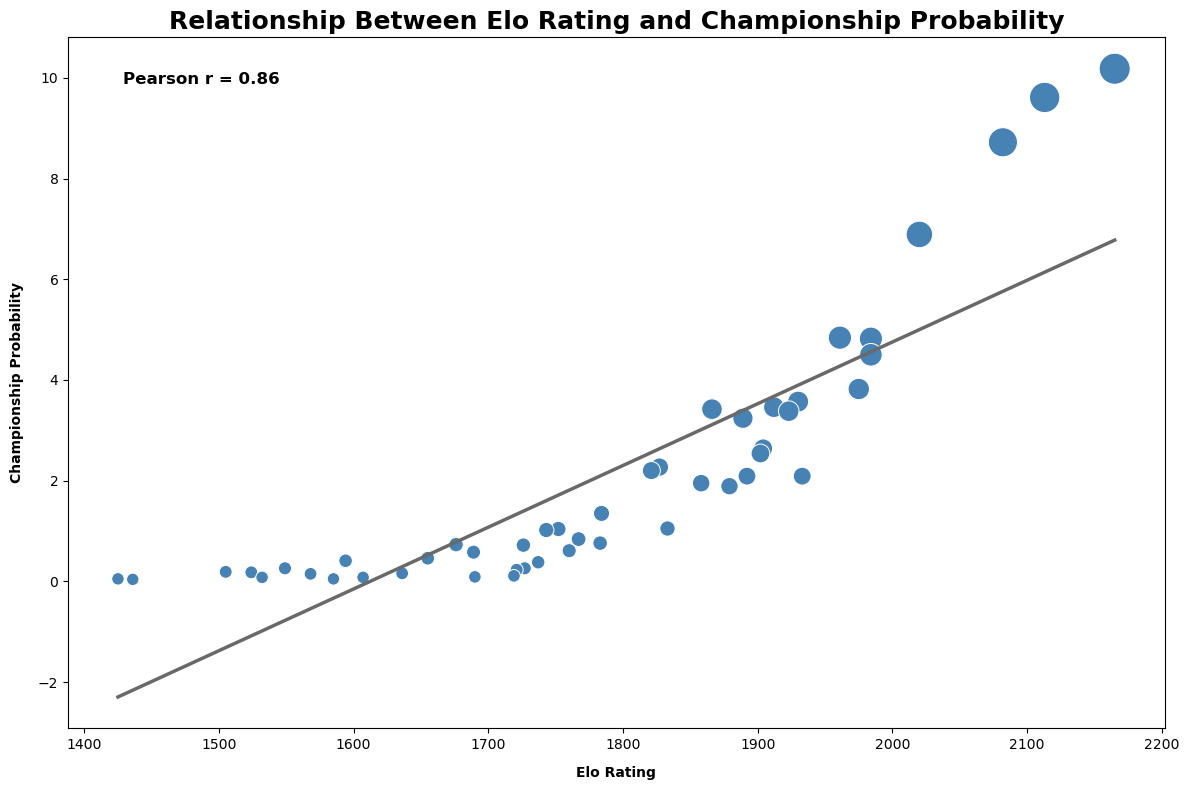

In [108]:
# Create consolidated dataframe with probabilites and elo ratings
probabilities_elo = probabilities.merge(elo_ratings_wc2026, left_on="country", right_on="country_full", how="left")
# Transform championship probability to percentage
probabilities_elo["champion_prob_pct"] = probabilities_elo["champion_prob"] * 100

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=probabilities_elo,
    x="total_points",
    y="champion_prob_pct",
    size="champion_prob_pct",
    sizes=(80, 500),
    color="steelblue",
    ax=ax,
    legend=False
)

# Correlation / regression line
sns.regplot(
    data=probabilities_elo,
    x="total_points",
    y="champion_prob_pct",
    scatter=False,
    ci=None,
    color="dimgrey",
    line_kws={"linewidth": 2.5},
    ax=ax
)

corr = probabilities_elo["total_points"].corr(probabilities_elo["champion_prob"])

ax.text(
    0.05,
    0.95,
    f"Pearson r = {corr:.2f}",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    verticalalignment="top"
)

plt.title("Relationship Between Elo Rating and Championship Probability", fontsize=18, fontweight="bold")
plt.xlabel("Elo Rating", labelpad=10, fontweight="bold")
plt.ylabel("Championship Probability", labelpad=10, fontweight="bold")

plt.tight_layout()
plt.show()